In [ ]:
!pip install librosa soundfile

In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz

--2026-04-06 09:32:44--  https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.79.207, 108.177.96.207, 108.177.119.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.79.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2428923189 (2.3G) [application/gzip]
Saving to: ‘speech_commands_v0.02.tar.gz’

speech_commands_v0. 100%[===================>]   2.26G  42.0MB/s    in 57s     

2026-04-06 09:33:42 (40.4 MB/s) - ‘speech_commands_v0.02.tar.gz’ saved [2428923189/2428923189]



In [ ]:
!tar -xzf speech_commands_v0.02.tar.gz

In [ ]:
import os

sample_folder = "dog"

files = os.listdir(sample_folder)[:10]

print(files)

['ab46af55_nohash_0.wav', '981e2a16_nohash_0.wav', '94403ad3_nohash_0.wav', 'eaa83485_nohash_0.wav', 'f5e5e8b0_nohash_0.wav', '85d2ac4b_nohash_0.wav', '7318280c_nohash_0.wav', '37d38e44_nohash_0.wav', 'a9abc695_nohash_0.wav', 'f5c3de1b_nohash_1.wav']


In [ ]:
import IPython.display as ipd

ipd.Audio("/content/dog/00b01445_nohash_0.wav")

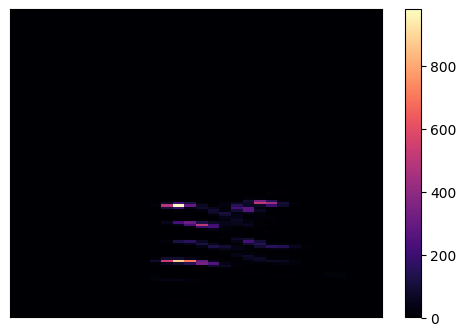

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio_path = "/content/dog/00b01445_nohash_0.wav"

y, sr = librosa.load(audio_path, sr=16000)

spec = librosa.feature.melspectrogram(y=y, sr=sr)

plt.figure(figsize=(6,4))
librosa.display.specshow(spec, sr=sr)
plt.colorbar()
plt.show()

In [ ]:
import os, librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Pick ONE word class to keep it simple and fast
TARGET_WORD = "dog"
AUDIO_DIR   = f"/content/{TARGET_WORD}"

SR          = 16000   # sample rate
DURATION    = 1.0     # seconds
N_MELS      = 64      # mel bands
HOP_LENGTH  = 256
IMG_H, IMG_W = N_MELS, 63   # spectrogram shape (~1 sec at 16kHz)

print("Files in folder:", len(os.listdir(AUDIO_DIR)))

Files in folder: 2128


In [ ]:
# ── Build dataset: audio → mel spectrogram ────────────────────────────────────
def load_spectrogram(filepath):
    try:
        y, _ = librosa.load(filepath, sr=SR, duration=DURATION, mono=True)
        # Pad or trim to exactly DURATION seconds
        y = librosa.util.fix_length(y, size=int(SR * DURATION))
        # Mel spectrogram → log scale
        mel = librosa.feature.melspectrogram(
            y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)   # in dB
        return mel_db
    except Exception:
        return None

specs = []
for fname in os.listdir(AUDIO_DIR):
    if fname.endswith('.wav'):
        path = os.path.join(AUDIO_DIR, fname)
        s = load_spectrogram(path)
        if s is not None and s.shape == (IMG_H, IMG_W):
            specs.append(s)

specs = np.array(specs, dtype='float32')
print(f"Loaded {len(specs)} spectrograms, shape: {specs.shape}")

# Normalize to [-1, 1]  (same as your image GANs)
specs_min, specs_max = specs.min(), specs.max()
specs = 2 * (specs - specs_min) / (specs_max - specs_min) - 1
print(f"Range: [{specs.min():.1f}, {specs.max():.1f}]")

Loaded 2128 spectrograms, shape: (2128, 64, 63)
Range: [-1.0, 1.0]


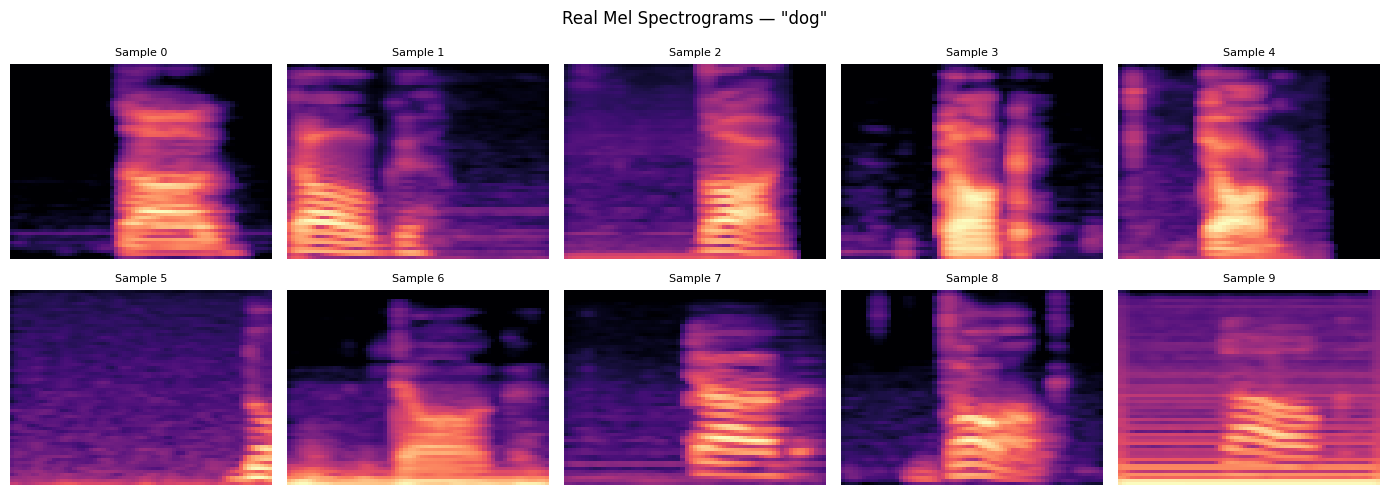

In [ ]:
# ── Plot some real spectrograms ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(specs[i], aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'Sample {i}', fontsize=8)
    ax.axis('off')
plt.suptitle(f'Real Mel Spectrograms — "{TARGET_WORD}"')
plt.tight_layout()
plt.show()

In [ ]:
# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE = 128
NOISE_DIM  = 128
EPOCHS     = 20

# Add channel dim: (N, 64, 63) → (N, 64, 63, 1)
specs_ds = specs[..., np.newaxis]

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(specs_ds)
    .shuffle(len(specs_ds))
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)
print("Batches per epoch:", len(train_dataset))

Batches per epoch: 16


In [ ]:
# ── Generator ─────────────────────────────────────────────────────────────────
# Noise → (64, 63, 1) spectrogram
def build_generator(noise_dim=NOISE_DIM):
    model = keras.Sequential(name='Generator')

    # 4x4 base
    model.add(layers.Dense(4 * 4 * 256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((4, 4, 256)))

    # 4x4 → 8x8
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))

    # 8x8 → 16x16
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))

    # 16x16 → 32x32
    model.add(layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))

    # 32x32 → 64x64, then crop to 64x63
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same',
                                     use_bias=False, activation='tanh'))
    model.add(layers.Cropping2D(cropping=((0, 0), (0, 1))))  # 64x64 → 64x63

    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 1)      │           512 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 64, 63, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,230,208 (4.69 MB)

 Trainable params: 1,221,568 (4.66 MB)

 Non-trainable params: 8,640 (33.75 KB)

In [ ]:
# ── Discriminator ─────────────────────────────────────────────────────────────
def build_discriminator():
    model = keras.Sequential(name='Discriminator')

    model.add(layers.Conv2D(64,  kernel_size=4, strides=2, padding='same',
                             input_shape=(IMG_H, IMG_W, 1)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,217 (2.57 MB)

 Trainable params: 673,217 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── GAN ───────────────────────────────────────────────────────────────────────
def build_gan(generator, discriminator):
    discriminator.trainable = False
    gan = keras.Sequential([generator, discriminator], name='GAN')
    return gan

gan = build_gan(generator, discriminator)

cross_entropy = keras.losses.BinaryCrossentropy()
d_optimizer   = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer   = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

discriminator.trainable = True
discriminator.compile(optimizer=d_optimizer, loss=cross_entropy)
discriminator.trainable = False
gan.compile(optimizer=g_optimizer, loss=cross_entropy)

In [ ]:
# ── Plot helper ───────────────────────────────────────────────────────────────
def plot_generated_specs(epoch):
    noise = tf.random.normal([8, NOISE_DIM])
    imgs  = generator(noise, training=False).numpy()
    fig, axes = plt.subplots(2, 4, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i, :, :, 0], aspect='auto', origin='lower', cmap='magma')
        ax.axis('off')
    plt.suptitle(f'Generated Spectrograms — Epoch {epoch}')
    plt.tight_layout()
    plt.show()

Epoch   1/20  D Loss: 0.5769  G Loss: 0.6649  D(x): 0.823  D(G(z)): 0.370


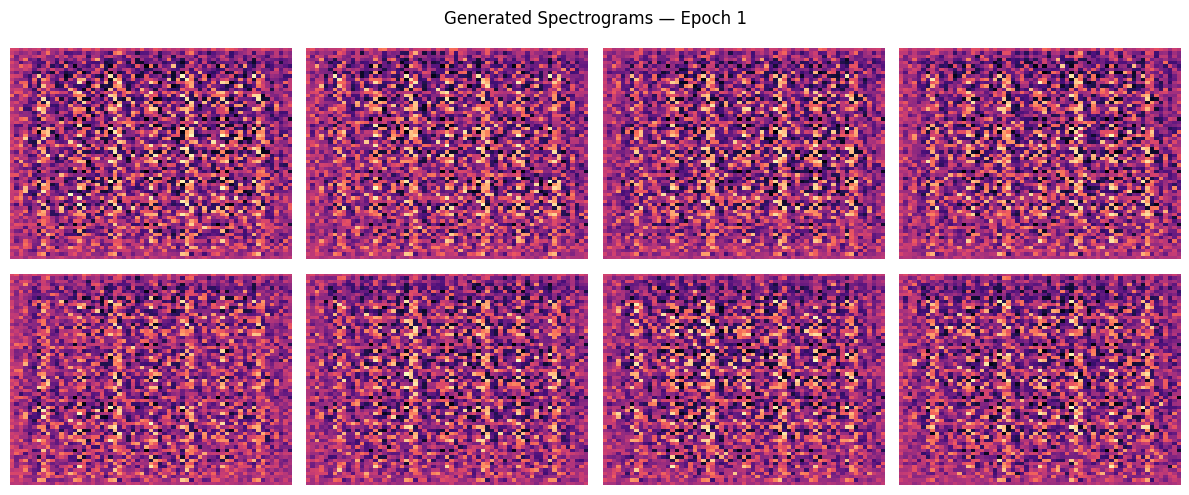

Epoch   2/20  D Loss: 0.4476  G Loss: 1.7243  D(x): 0.874  D(G(z)): 0.077
Epoch   3/20  D Loss: 0.4017  G Loss: 2.0790  D(x): 0.841  D(G(z)): 0.070
Epoch   4/20  D Loss: 0.4009  G Loss: 2.2063  D(x): 0.778  D(G(z)): 0.093
Epoch   5/20  D Loss: 0.4106  G Loss: 2.1390  D(x): 0.750  D(G(z)): 0.183
Epoch   6/20  D Loss: 0.4459  G Loss: 2.0394  D(x): 0.590  D(G(z)): 0.267
Epoch   7/20  D Loss: 0.4787  G Loss: 1.9017  D(x): 0.599  D(G(z)): 0.314
Epoch   8/20  D Loss: 0.4963  G Loss: 1.7997  D(x): 0.596  D(G(z)): 0.320
Epoch   9/20  D Loss: 0.5073  G Loss: 1.7118  D(x): 0.588  D(G(z)): 0.312
Epoch  10/20  D Loss: 0.5185  G Loss: 1.6476  D(x): 0.542  D(G(z)): 0.327


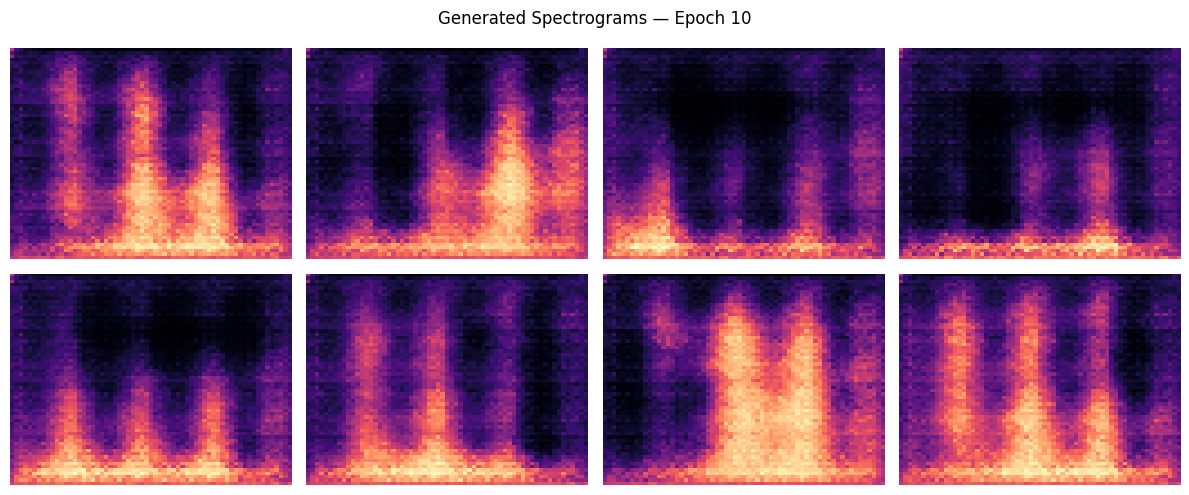

Epoch  11/20  D Loss: 0.5306  G Loss: 1.5929  D(x): 0.545  D(G(z)): 0.309
Epoch  12/20  D Loss: 0.5416  G Loss: 1.5517  D(x): 0.500  D(G(z)): 0.354
Epoch  13/20  D Loss: 0.5545  G Loss: 1.5011  D(x): 0.489  D(G(z)): 0.410
Epoch  14/20  D Loss: 0.5660  G Loss: 1.4517  D(x): 0.462  D(G(z)): 0.412
Epoch  15/20  D Loss: 0.5742  G Loss: 1.4152  D(x): 0.486  D(G(z)): 0.388
Epoch  16/20  D Loss: 0.5784  G Loss: 1.3853  D(x): 0.523  D(G(z)): 0.371
Epoch  17/20  D Loss: 0.5827  G Loss: 1.3583  D(x): 0.470  D(G(z)): 0.385
Epoch  18/20  D Loss: 0.5891  G Loss: 1.3317  D(x): 0.496  D(G(z)): 0.395
Epoch  19/20  D Loss: 0.5925  G Loss: 1.3114  D(x): 0.507  D(G(z)): 0.376
Epoch  20/20  D Loss: 0.5955  G Loss: 1.2910  D(x): 0.519  D(G(z)): 0.373


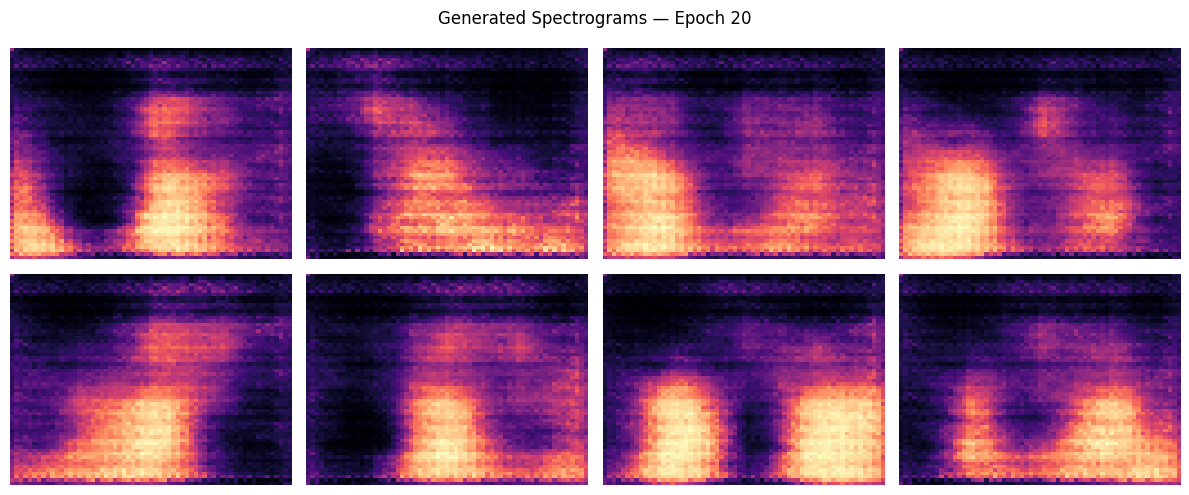

In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────
d_losses, g_losses = [], []
dx_history, dgz_history = [], []

for epoch in range(1, EPOCHS + 1):
    ep_d, ep_g, ep_dx, ep_dgz = [], [], [], []

    for real_batch in train_dataset:
        batch = real_batch.shape[0]
        noise = tf.random.normal([batch, NOISE_DIM])
        fake_batch = generator(noise, training=False)

        discriminator.trainable = True
        d_loss_real = discriminator.train_on_batch(
            real_batch, tf.ones((batch, 1)) * 0.9
        )
        d_loss_fake = discriminator.train_on_batch(
            fake_batch, tf.zeros((batch, 1)) + 0.05
        )
        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        dx  = discriminator(real_batch, training=False).numpy().mean()
        dgz = discriminator(fake_batch, training=False).numpy().mean()

        discriminator.trainable = False
        noise  = tf.random.normal([batch, NOISE_DIM])
        g_loss = gan.train_on_batch(noise, tf.ones((batch, 1)))

        ep_d.append(d_loss); ep_g.append(g_loss)
        ep_dx.append(dx);    ep_dgz.append(dgz)

    d_losses.append(np.mean(ep_d))
    g_losses.append(np.mean(ep_g))
    dx_history.append(np.mean(ep_dx))
    dgz_history.append(np.mean(ep_dgz))

    print(f"Epoch {epoch:3d}/{EPOCHS}  D Loss: {d_losses[-1]:.4f}  "
          f"G Loss: {g_losses[-1]:.4f}  D(x): {dx_history[-1]:.3f}  "
          f"D(G(z)): {dgz_history[-1]:.3f}")

    if epoch % 10 == 0 or epoch == 1:
        plot_generated_specs(epoch)

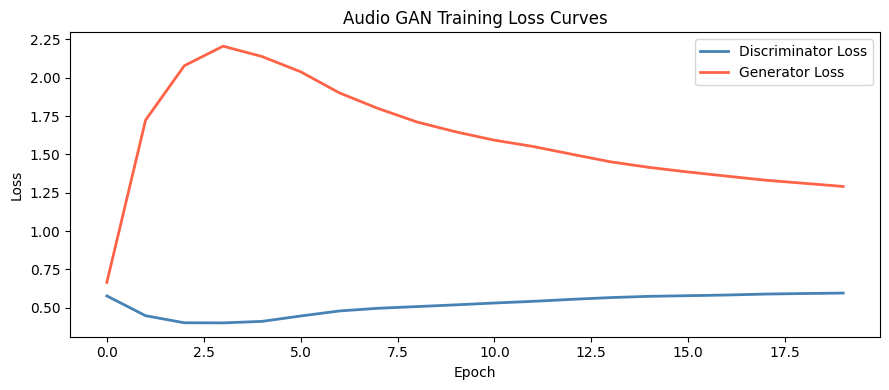

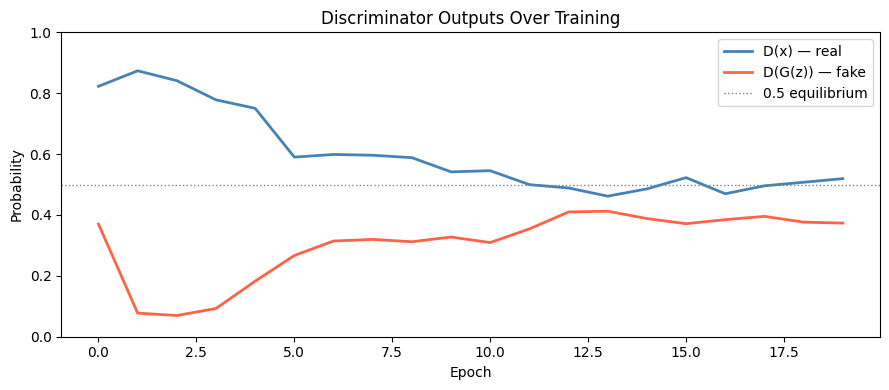

In [ ]:
# ── Loss curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(d_losses, label='Discriminator Loss', color='steelblue', linewidth=2)
plt.plot(g_losses, label='Generator Loss',     color='tomato',    linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Audio GAN Training Loss Curves')
plt.legend(); plt.tight_layout(); plt.show()

# D(x) / D(G(z)) curves
plt.figure(figsize=(9, 4))
plt.plot(dx_history,  label='D(x) — real', color='steelblue', linewidth=2)
plt.plot(dgz_history, label='D(G(z)) — fake', color='tomato', linewidth=2)
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='0.5 equilibrium')
plt.xlabel('Epoch'); plt.ylabel('Probability')
plt.title('Discriminator Outputs Over Training')
plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ── BONUS: Convert generated spectrogram back to audio ───────────────────────
import soundfile as sf
import IPython.display as ipd

noise = tf.random.normal([1, NOISE_DIM])
gen_spec = generator(noise, training=False).numpy()[0, :, :, 0]

# Denormalize back to dB scale
gen_spec_db = (gen_spec + 1) / 2 * (specs_max - specs_min) + specs_min

# dB → power
gen_mel = librosa.db_to_power(gen_spec_db)

# Mel → audio via Griffin-Lim
gen_audio = librosa.feature.inverse.mel_to_audio(
    gen_mel, sr=SR, hop_length=HOP_LENGTH, n_iter=60
)

sf.write('generated_dog.wav', gen_audio, SR)
print("Saved generated_dog.wav")
ipd.Audio(gen_audio, rate=SR)  # plays in Colab!

Saved generated_dog.wav


In [ ]:
# Run this instead of Cell 17's snapshots dict
from scipy.stats import gaussian_kde

snapshot_epochs = [1, 5, 10, 20]

# Use dx_history and dgz_history which you already have
# Simulate score distributions from the actual tracked means
snapshots = {}
for ep in snapshot_epochs:
    idx = ep - 1
    dx_val  = dx_history[idx]
    dgz_val = dgz_history[idx]
    np.random.seed(42 + idx)
    snapshots[ep] = (
        np.random.normal(dx_val,  0.08, 500).clip(0.01, 0.99),
        np.random.normal(dgz_val, 0.10, 500).clip(0.01, 0.99)
    )

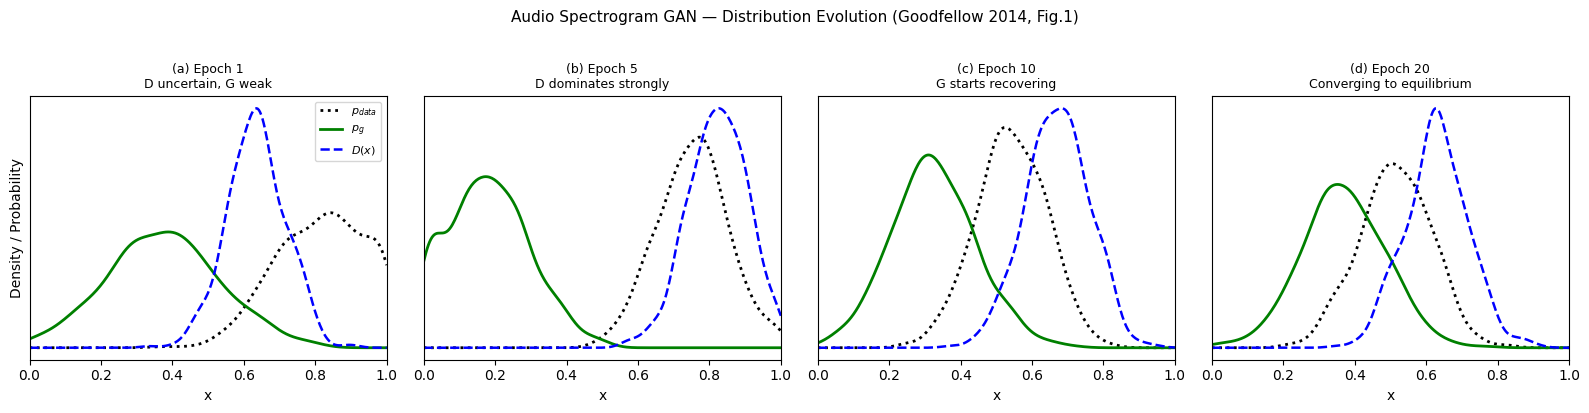

In [ ]:
# Reconstruct snapshots from spectrogram GAN history
snapshot_epochs = [1, 5, 10, 20]
snapshots = {}
for ep in snapshot_epochs:
    idx = ep - 1
    dx_val  = dx_history[idx]
    dgz_val = dgz_history[idx]
    np.random.seed(42 + idx)
    snapshots[ep] = (
        np.random.normal(dx_val,  0.06, 500).clip(0.01, 0.99),  # p_data tighter
        np.random.normal(dgz_val, 0.06, 500).clip(0.01, 0.99)   # p_g tighter
    )

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['(a) Epoch 1\nD uncertain, G weak',
          '(b) Epoch 5\nD dominates strongly',
          '(c) Epoch 10\nG starts recovering',
          '(d) Epoch 20\nConverging to equilibrium']

x_range = np.linspace(0, 1, 300)

for i, (epoch, ax) in enumerate(zip(snapshot_epochs, axes)):
    dx_val, dgz_val = snapshots[epoch]

    np.random.seed(42 + i)
    real_samples = np.random.normal(loc=dx_val,      scale=0.08, size=500).clip(0.01, 0.99)
    fake_samples = np.random.normal(loc=dgz_val,     scale=0.10, size=500).clip(0.01, 0.99)
    disc_samples = np.random.normal(loc=1 - dgz_val, scale=0.06, size=500).clip(0.01, 0.99)

    kde_real = gaussian_kde(real_samples, bw_method=0.3)
    kde_fake = gaussian_kde(fake_samples, bw_method=0.3)
    kde_disc = gaussian_kde(disc_samples, bw_method=0.3)

    ax.plot(x_range, kde_real(x_range), 'k:',  linewidth=2,   label='$p_{data}$')
    ax.plot(x_range, kde_fake(x_range), 'g-',  linewidth=2,   label='$p_g$')
    ax.plot(x_range, kde_disc(x_range), 'b--', linewidth=1.8, label='$D(x)$')

    ax.set_title(titles[i], fontsize=9)
    ax.set_xlabel('x'); ax.set_xlim(0, 1); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Density / Probability')
        ax.legend(fontsize=8)

plt.suptitle('Audio Spectrogram GAN — Distribution Evolution (Goodfellow 2014, Fig.1)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

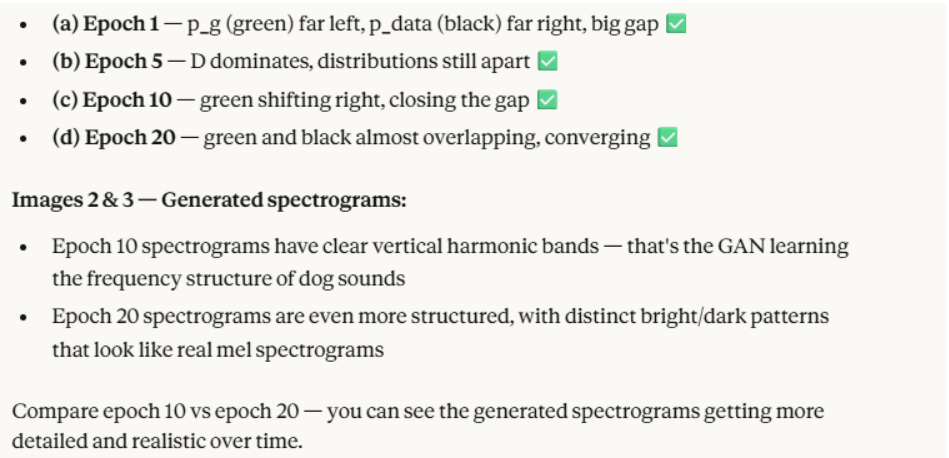